In [1]:
%load_ext autoreload
%autoreload 2

In [1]:

from loguru import logger
import sys
from tqdm.notebook import tqdm
logger.remove()
logger.add(sys.stderr, level="INFO")
import os

## Evaluate results

In [2]:
import pandas as pd
from evaluation_utils import ActivityEvaluator
import numpy as np

In [3]:
def get_result(ground_truth_folder, dataset, llms, num_generation, approaches, folder):
    results = []

    for approach in approaches:
        ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"

        result = {}
        result["approach"] = approach
        for llm in llms:
            folder_path = f"{folder}/{llm}"
            if approach == "greedy":
                evaluator = ActivityEvaluator(
                    folder_path,
                    dataset,
                )
                metrics = evaluator.evaluate_greedy_result()
            else:
                evaluator = ActivityEvaluator(
                    folder_path, dataset
                )
                df = pd.read_csv(f"{folder_path}/{dataset}/results_{approach}_{num_generation}.csv")["0"].tolist()
                metrics = evaluator.evaluate_solutions(df)
            

            for metric_name in ["precision", "recall", "f1", "consistency"]:
                result[f"{metric_name}_{llm}"] = metrics[metric_name]
        results.append(result)

    return results

In [4]:
folder = "results"
ground_truth_folder = "data"
approaches = ["greedy", "mv", "abscon"]
llms = ["gpt-4o-mini", "gpt-4o", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]

dataset = "paged"
num_generation = 10

In [5]:
results = get_result(ground_truth_folder, dataset, llms, num_generation, approaches, folder)

In [6]:
results_df = pd.DataFrame(results)
results_df[results_df.select_dtypes(include=['number']).columns] *= 100
results_df = results_df[["f1_gpt-4o-mini", "f1_gpt-4o","f1_Meta-Llama-3.1-8B-Instruct", "f1_Meta-Llama-3.1-70B-Instruct"]]
print(results_df.round(2).to_markdown(index=False))

|   f1_gpt-4o-mini |   f1_gpt-4o |   f1_Meta-Llama-3.1-8B-Instruct |   f1_Meta-Llama-3.1-70B-Instruct |
|-----------------:|------------:|--------------------------------:|---------------------------------:|
|            82.96 |       85.87 |                           84.65 |                            86.29 |
|            81.85 |       84.99 |                           81.46 |                            85.79 |
|            84.04 |       86.36 |                           85.32 |                            86.62 |


In [7]:
results_df.loc[2] - results_df.loc[0]

f1_gpt-4o-mini                    1.084467
f1_gpt-4o                         0.487153
f1_Meta-Llama-3.1-8B-Instruct     0.665601
f1_Meta-Llama-3.1-70B-Instruct    0.328417
dtype: float64

In [8]:
results_df = pd.DataFrame(results)
results_df[results_df.select_dtypes(include=['number']).columns] *= 100
# results_df = results_df[["approach", "precision", "recall", "f1", "consistency"]]
# results_df.columns = ["approach", "P", "R", "F1", "Con"]
print(results_df.round(2).to_latex(index=False, header=False))

\begin{tabular}{lrrrrrrrrrrrrrrrr}
\toprule
greedy & 84.43 & 82.37 & 82.96 & 95.40 & 86.88 & 85.61 & 85.87 & 96.63 & 84.23 & 85.84 & 84.65 & 94.48 & 85.92 & 87.39 & 86.29 & 93.25 \\
    mv & 86.12 & 79.03 & 81.85 & 66.26 & 88.37 & 82.90 & 84.99 & 71.47 & 86.36 & 78.48 & 81.46 & 50.31 & 86.70 & 85.63 & 85.79 & 69.94 \\
abscon & 84.38 & 84.47 & 84.04 & 99.08 & 86.90 & 86.55 & 86.36 & 99.39 & 84.75 & 86.59 & 85.32 & 98.47 & 85.93 & 87.92 & 86.62 & 96.32 \\
\bottomrule
\end{tabular}



C:\Users\chenp\AppData\Local\Temp\ipykernel_40180\2746370661.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(results_df.round(2).to_latex(index=False, header=False))


In [9]:
results_df
results_df_index = results_df.set_index("approach", inplace=False)

In [10]:
diff = results_df_index.loc["abscon", :] - results_df_index.loc["greedy", :]
recall_diff = [value for key, value in diff.items() if "recall" in key]
print(f"Min improvement: {min(recall_diff)}, max improvement: {max(recall_diff)}, average improvement: {np.mean(recall_diff)}")

Min improvement: 0.5211839566674001, max improvement: 2.105633775683202, average improvement: 1.0780559485548586


In [11]:
f1_diff = [value for key, value in diff.items() if "f1" in key]
print(f"Min improvement: {min(f1_diff)}, max improvement: {max(f1_diff)}, average improvement: {np.mean(f1_diff)}")

Min improvement: 0.32841746516758974, max improvement: 1.0844671706207833, average improvement: 0.6414096314664768


## Plotting

In [12]:
from tqdm.notebook import tqdm
import pandas as pd
from evaluation_utils import ActivityEvaluator
import numpy as np

In [27]:
folder = "results"
ground_truth_folder = "data"
approaches = ["mv", "greedy", "abscon"]
llms = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]# ["Meta-Llama-3.1-70B-Instruct"]

dataset = "paged"
num_generations = range(1, 21)

In [28]:
results = []

for num_generation in tqdm(num_generations):
    result = {}
    for approach in approaches:
        ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"

        result[approach] = {}
        for llm in llms:
            folder_path = f"{folder}/{llm}"
            if approach == "greedy":
                evaluator = ActivityEvaluator(
                    folder_path,
                    dataset,
                    ground_truth_path,
                )
                metrics = evaluator.evaluate_greedy_result()
            else:
                evaluator = ActivityEvaluator(
                    folder_path, dataset, ground_truth_path
                )
                df = pd.read_csv(f"{folder_path}/{dataset}/results_{approach}_{num_generation}.csv")["0"].tolist()
                metrics = evaluator.evaluate_solutions(df)
            result[approach][llm] = metrics
    results.append(result)

  0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
for i in range(len(results)):
    results[i]["max"] = {}
    results[i]["median"] = {}
for llm in llms:
    folder_path = f"{folder}/{llm}"
    evaluator = ActivityEvaluator(
        folder_path, dataset, ground_truth_path
    )

    for i in tqdm(range(len(results))):
        results[i]["max"][llm] = evaluator.evaluate_individual(
            i + 1, dataset=dataset, aggregator=max
        )
        results[i]["median"][llm] = evaluator.evaluate_individual(
            i + 1, dataset=dataset, aggregator=np.median
        )

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [40]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', "ieee"])

# models = ["llama_8b", "llama_70b", "gpt_4o_mini", "gpt_4o"]
models = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]
model_names = ["Llama3.1 8b", "Llama3.1 70b"]
metrics = ["f1", "consistency"]
approaches = ["mv", "abscon", "max", "median", "greedy"]
approach_names = ["MV", "AbsCon", "Best", "Median", "Direct"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] , [71, 133, 90],  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

In [41]:
llms

['Meta-Llama-3.1-8B-Instruct', 'Meta-Llama-3.1-70B-Instruct']

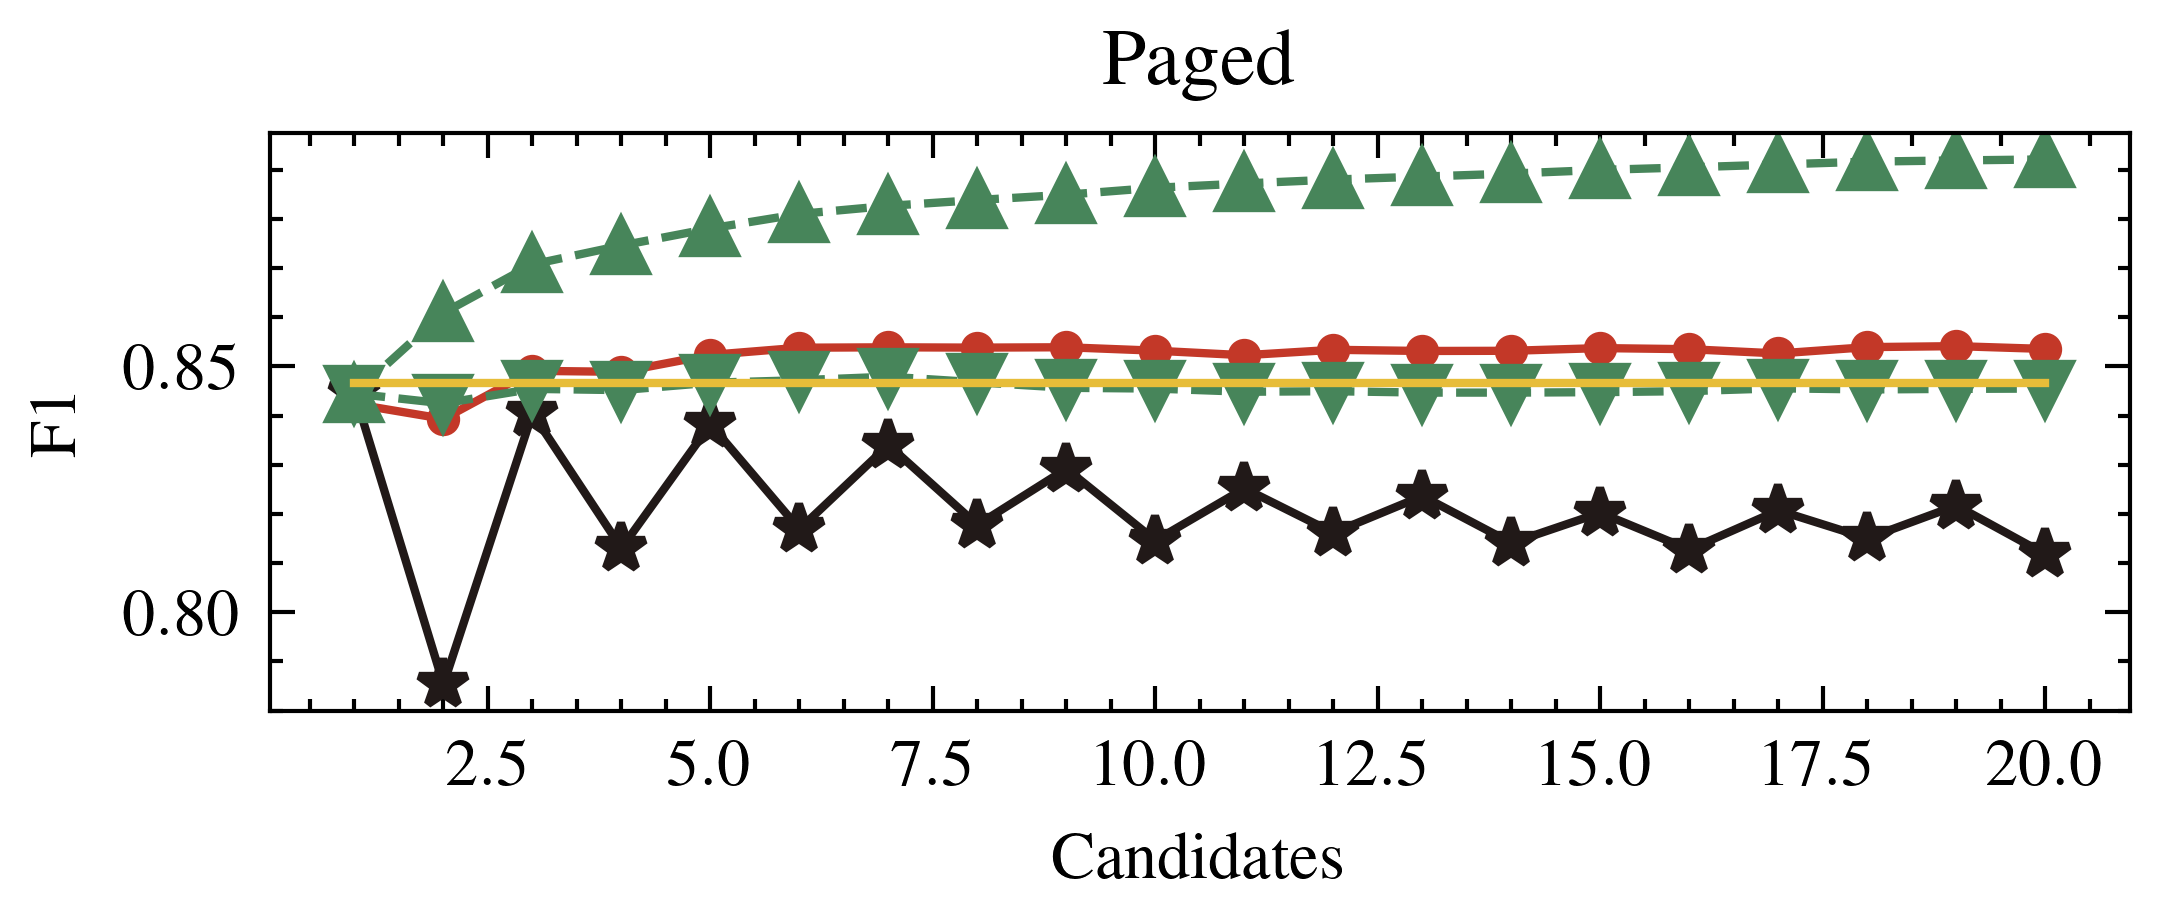

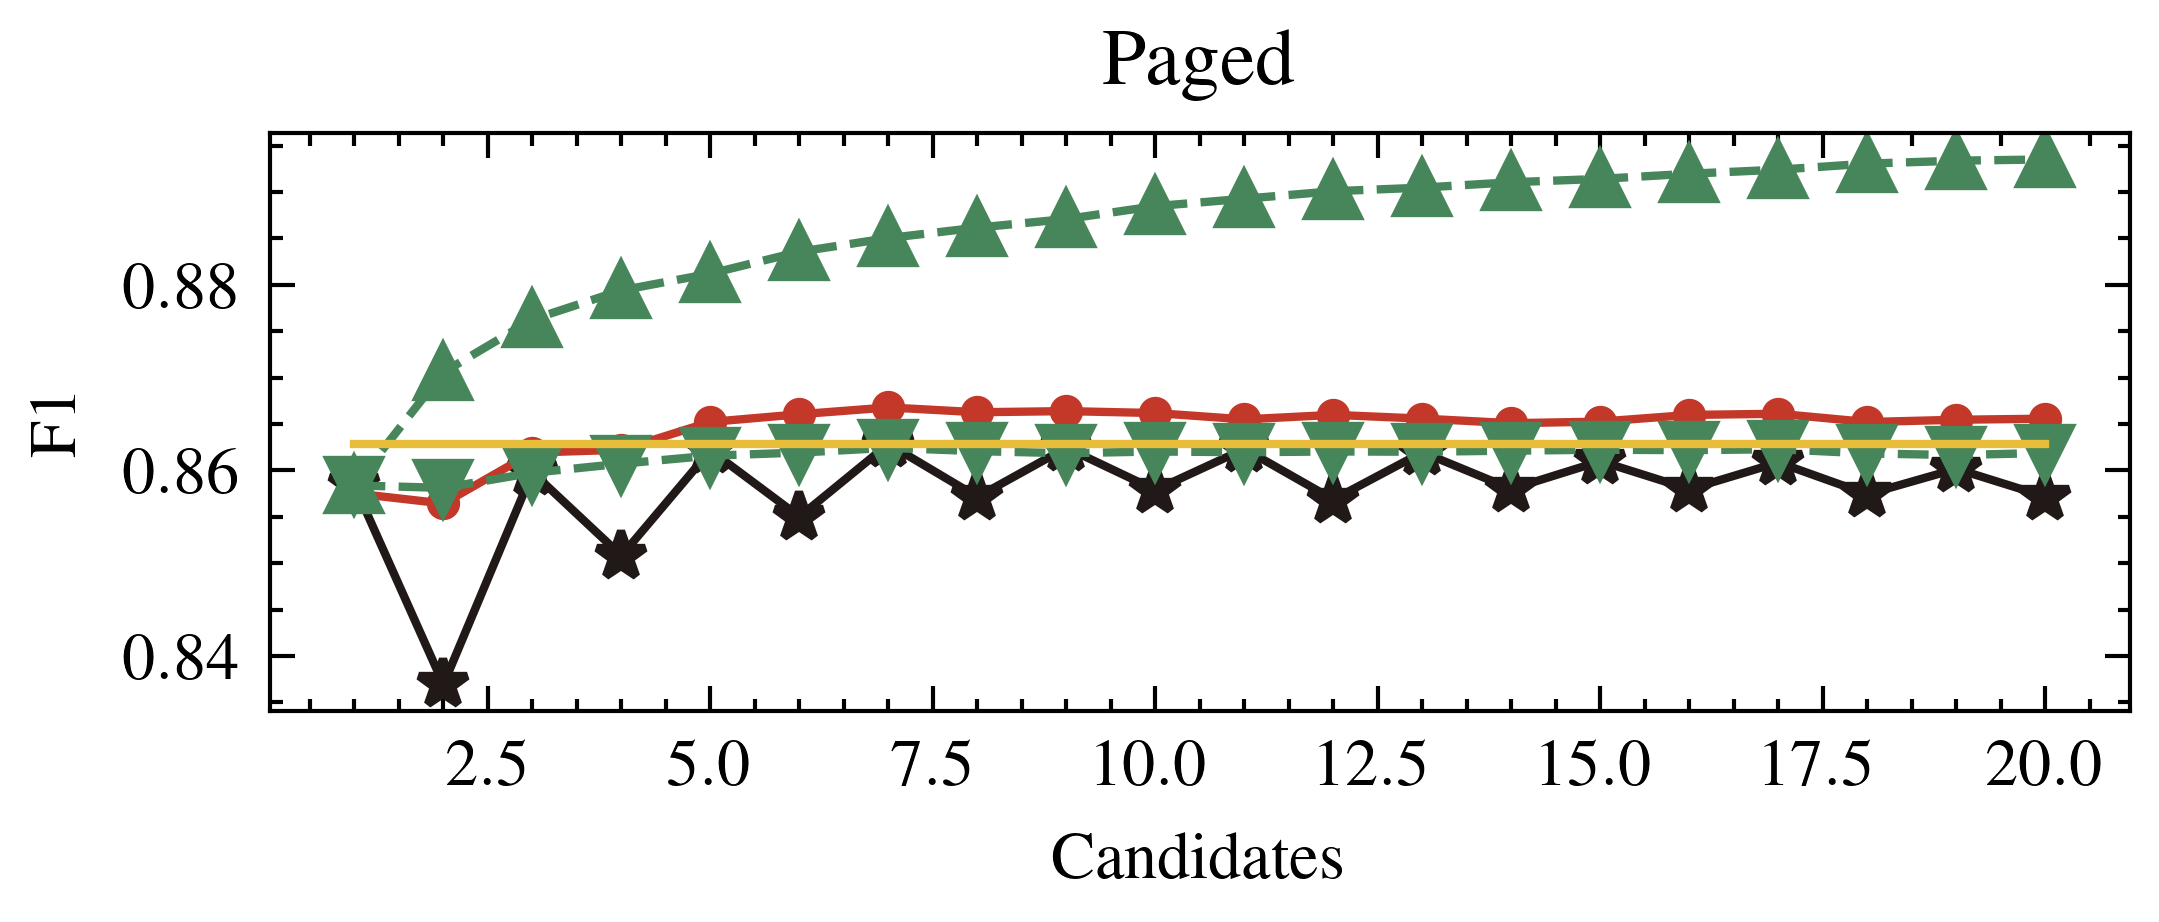

In [42]:
metric = "f1"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.25))
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["mv", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    # plt.legend(shadow=True, ncol=2)
    plt.title("Paged")
    plt.ylabel("F1")
    plt.xlabel("Candidates")
    # plt.savefig("Paged.png", dpi=300)
    plt.show()        

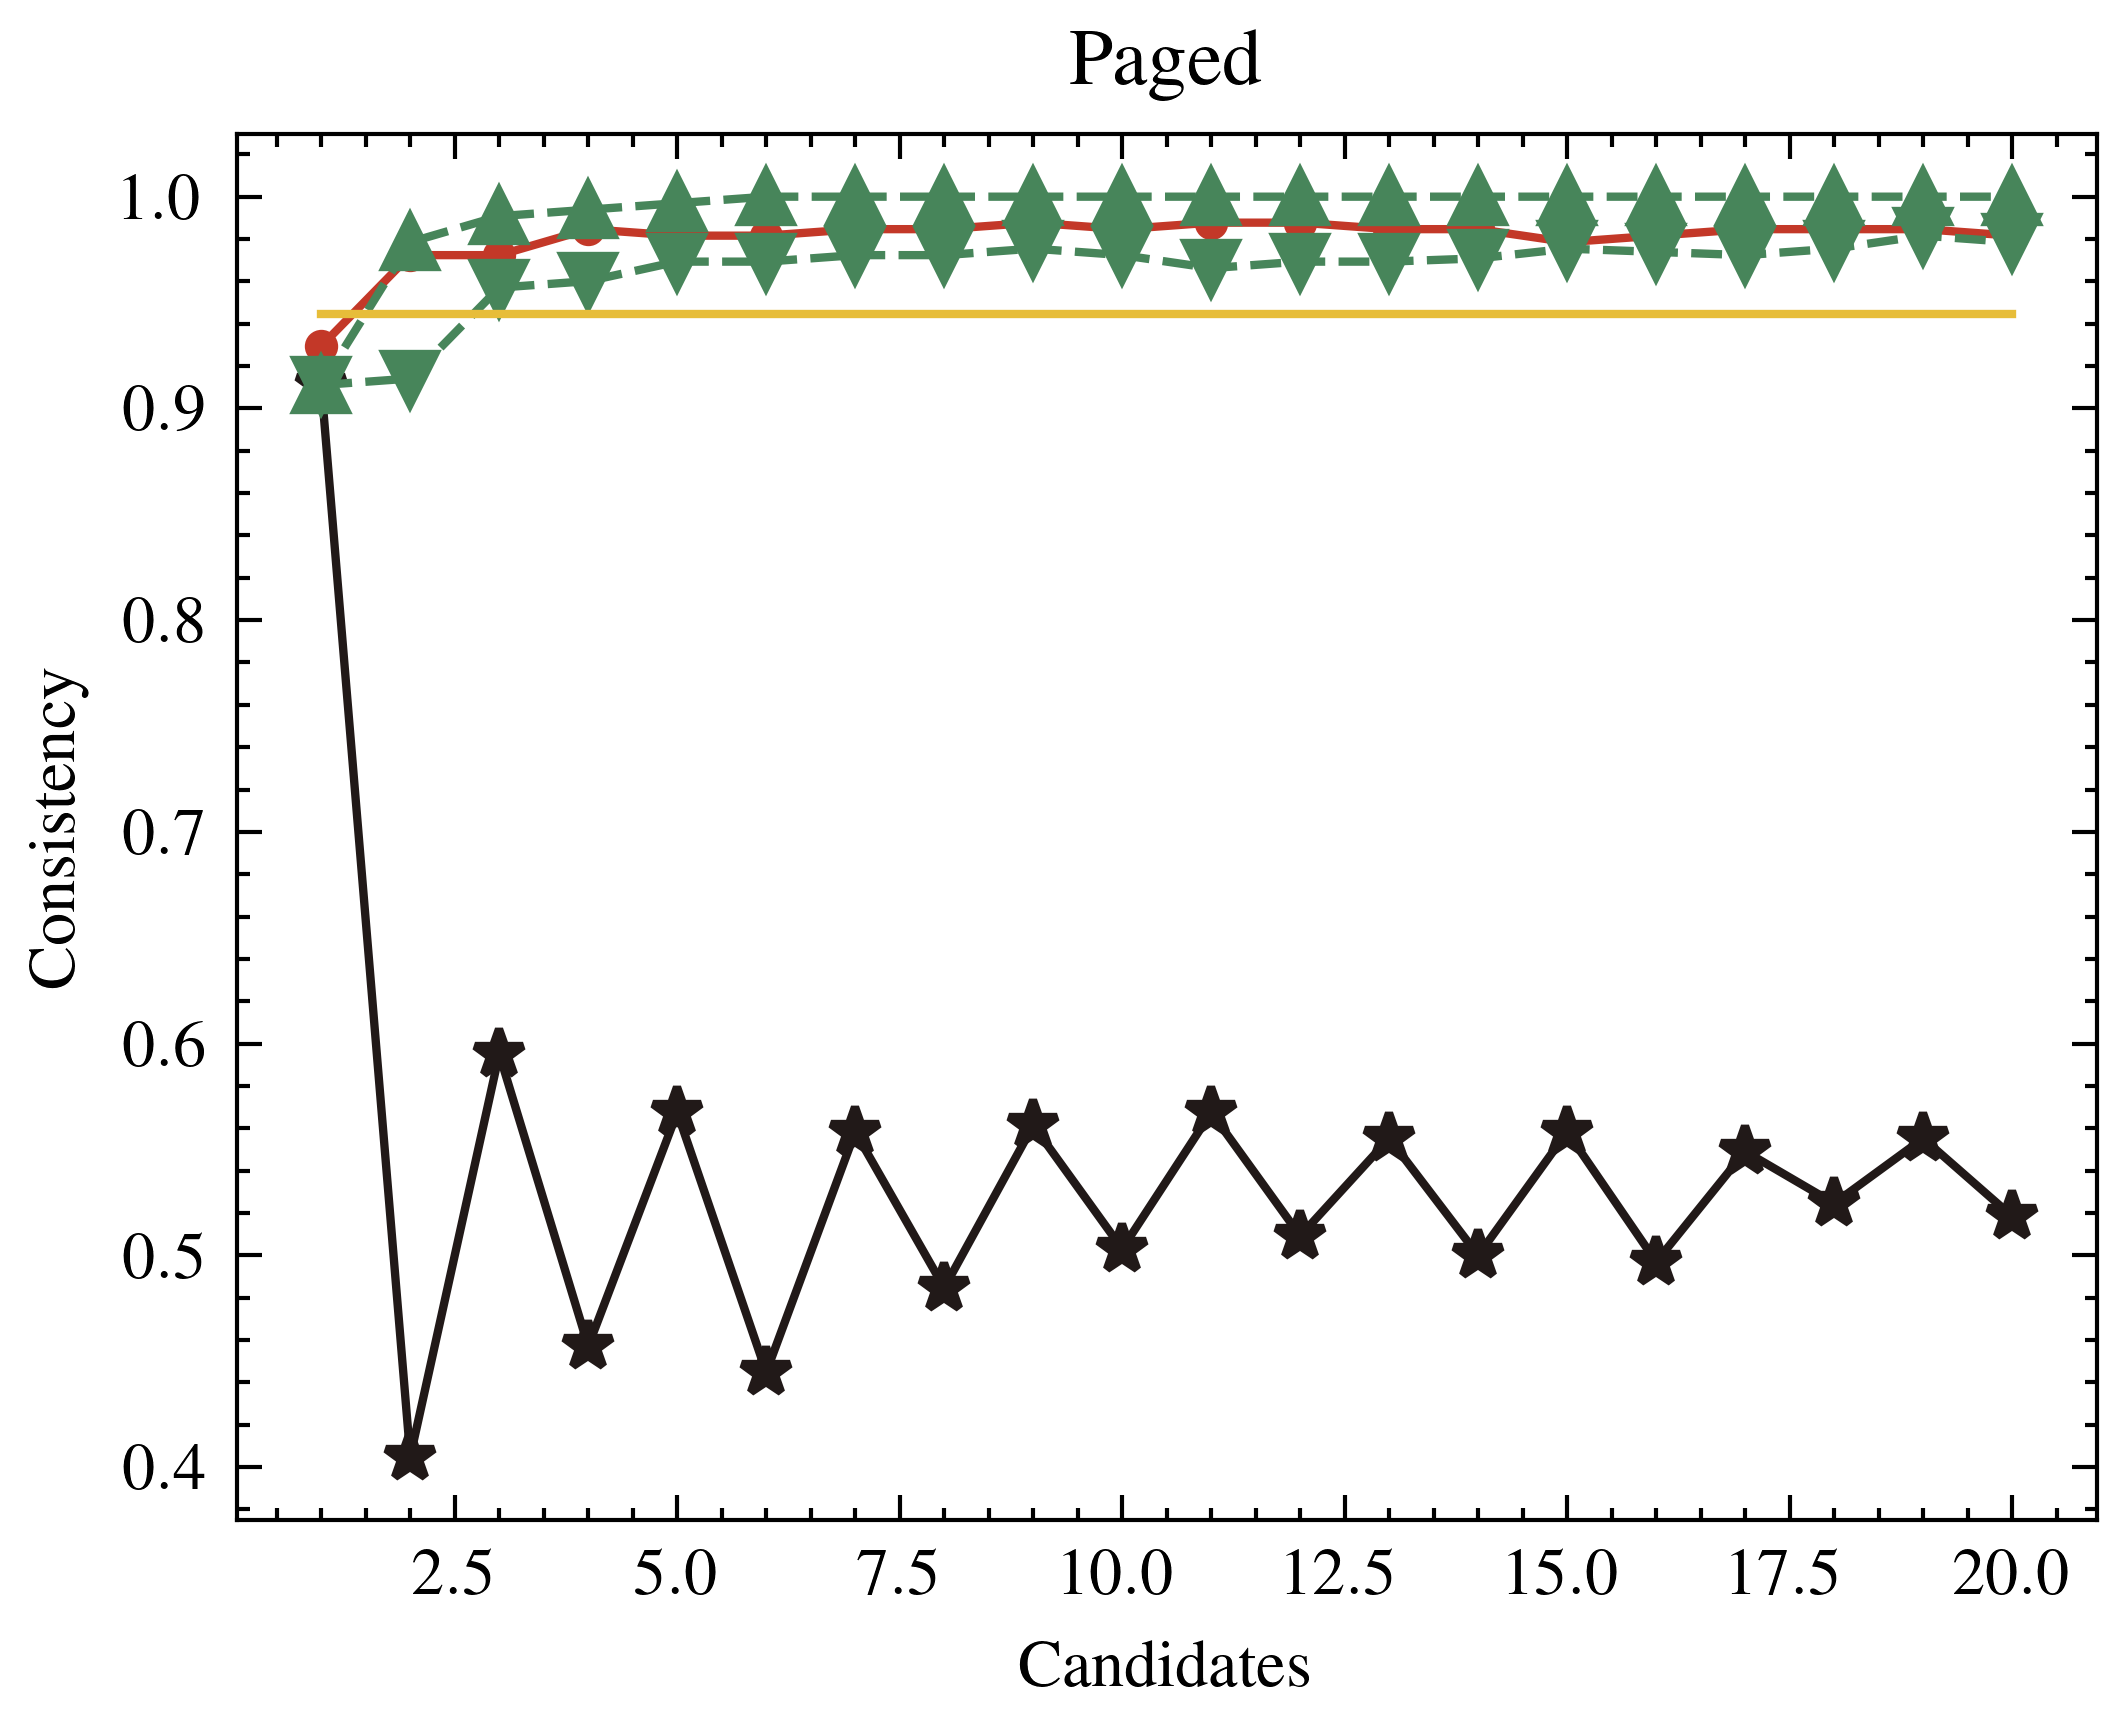

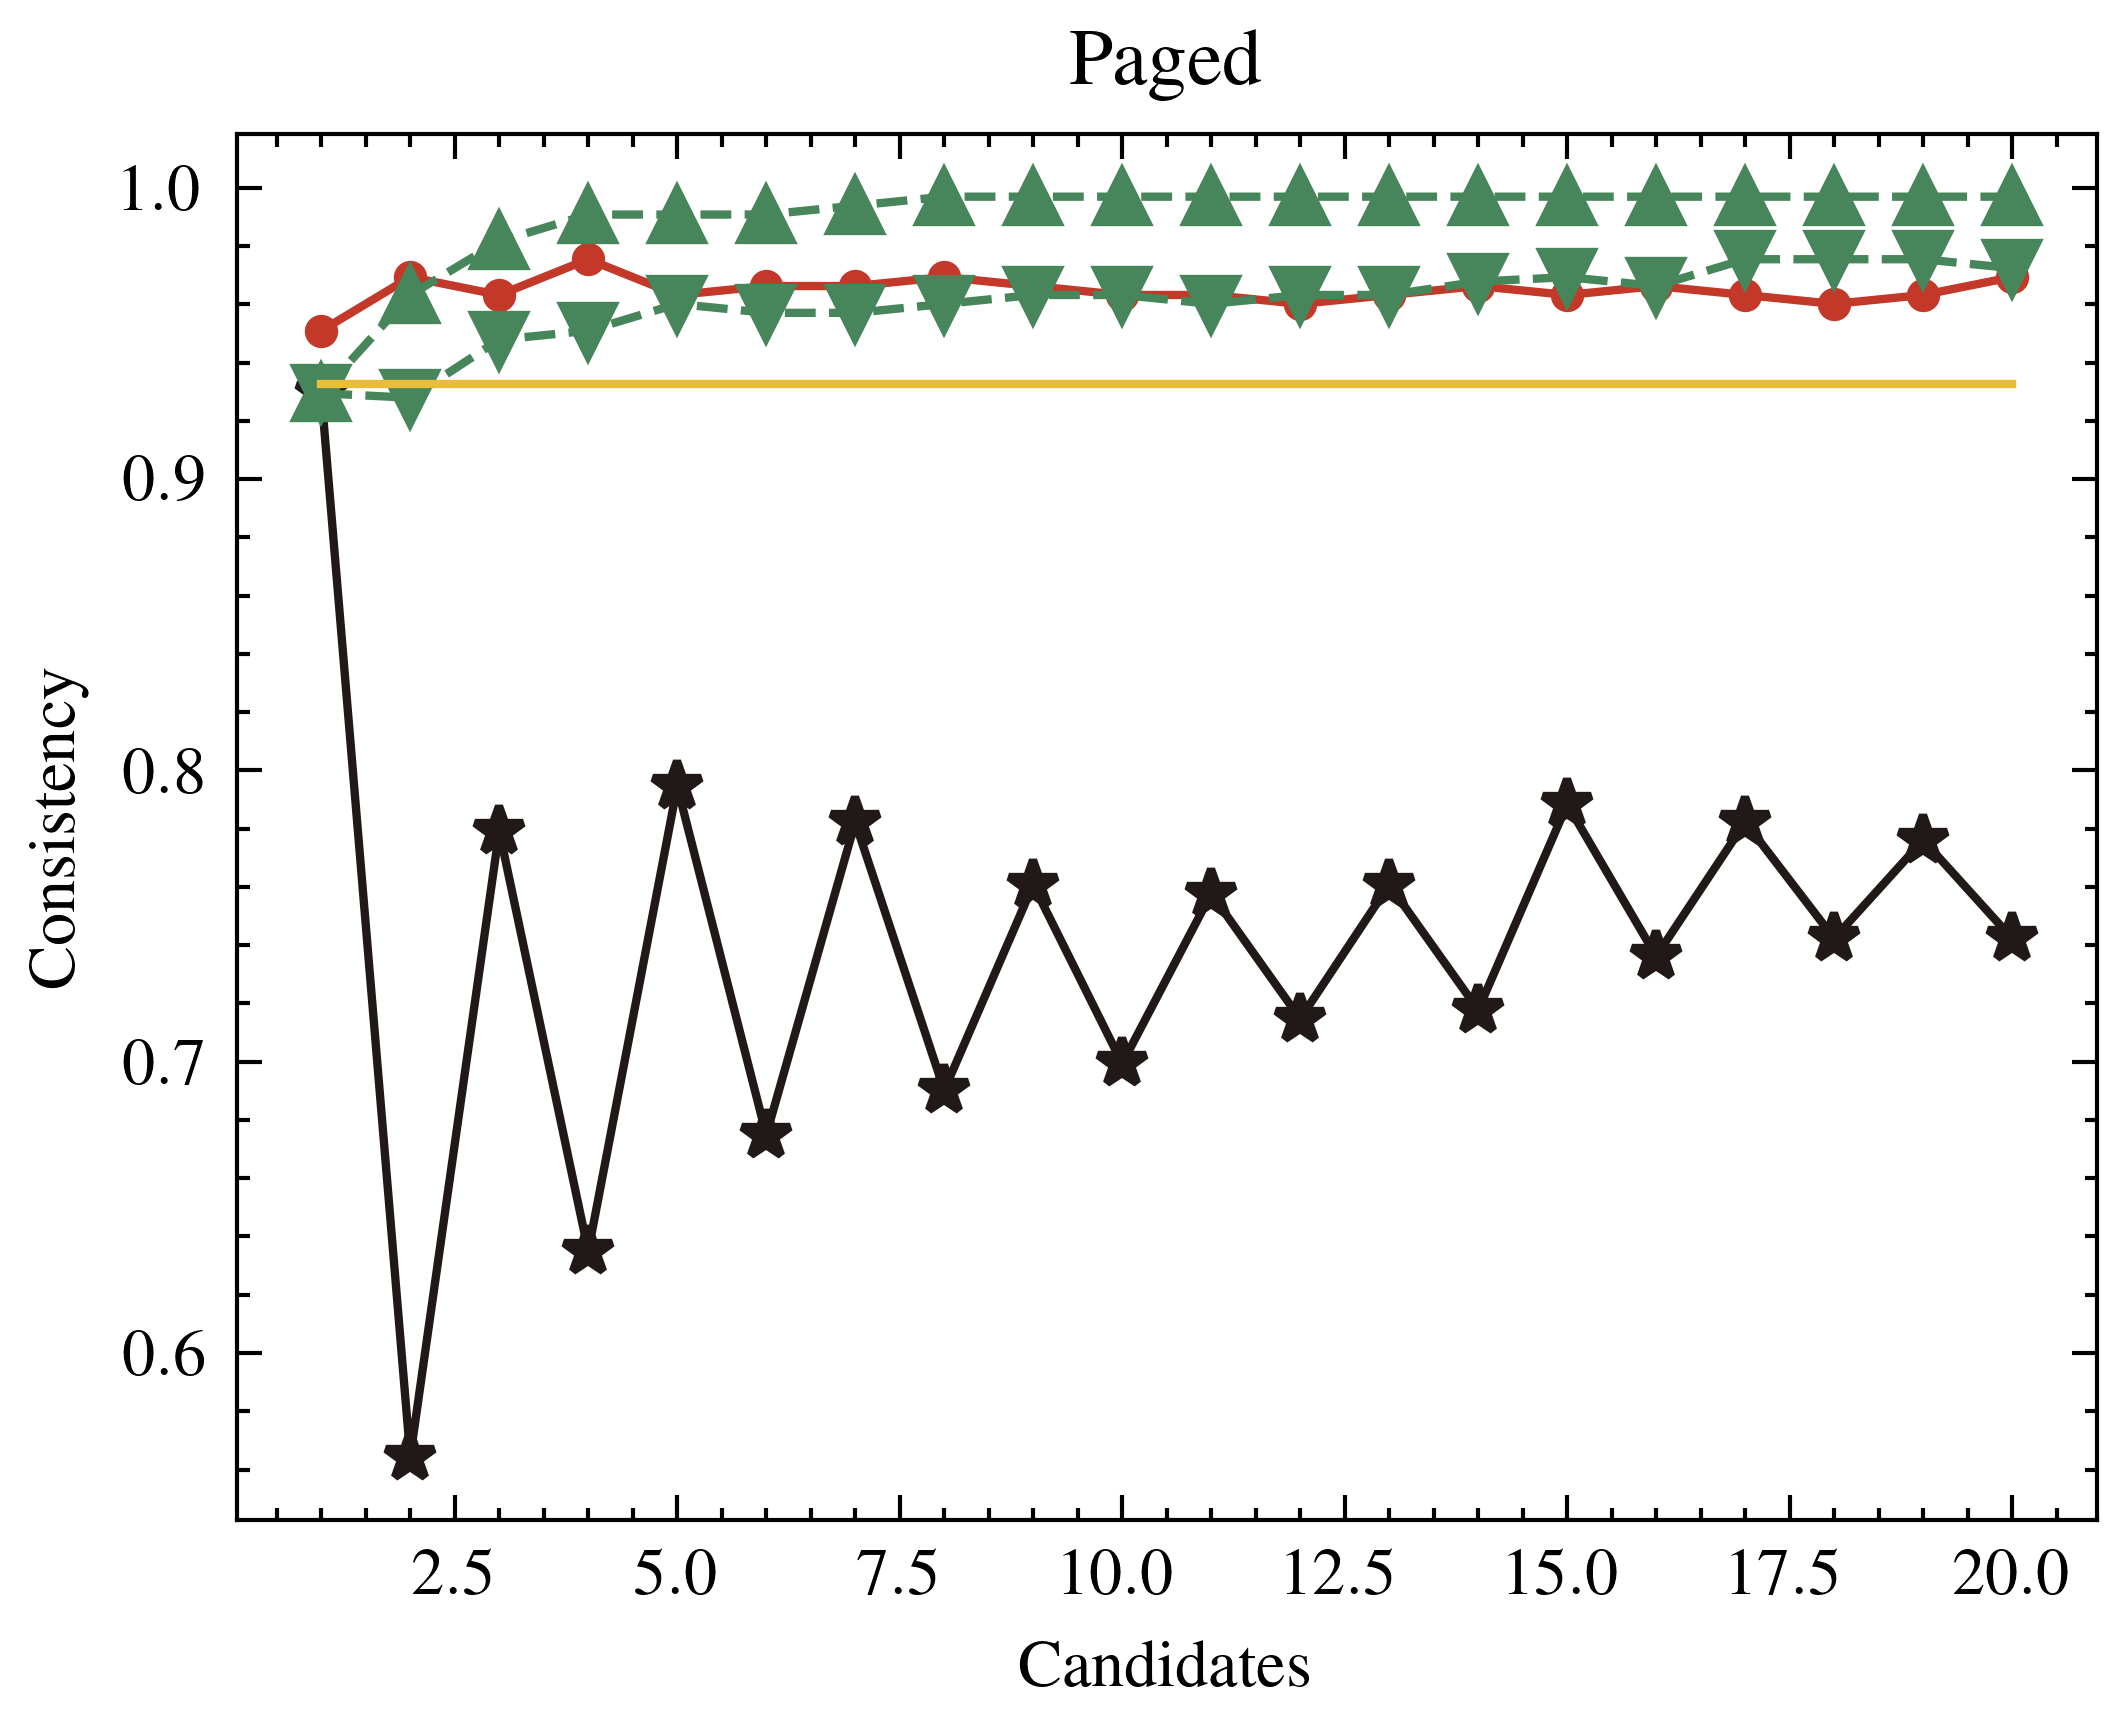

In [47]:
metric = "consistency"
x = num_generations
f1_values = []
approaches = ["mv", "abscon", "max", "median", "greedy"]
approach_names = ["MV", "AbsCon", "Best", "Median", "Direct"]

for i, llm in enumerate(models):
    plt.figure(figsize=(4,3))
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["mv", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    # plt.legend(shadow=True, ncol=2)
    plt.title("Paged")
    plt.ylabel("Consistency")
    plt.xlabel("Candidates")
    # plt.savefig("Paged.png", dpi=300)
    plt.show()        

In [ ]:
from scipy.stats import spearmanr

spearmanr(f1_values, consistency_values, alternative="greater")

## RQ3: Impact of Temperature

In [ ]:
folder = "results"
ground_truth_folder = "data"
approaches = ["abscon"]
llms = ["Meta-Llama-3.1-70B-Instruct", "gpt-4o-mini"]

dataset = "paged"
num_generation = 10

temperatures = ["0.2", "0.5", "0.7", "1"]

In [ ]:
temperature_results = {}

for temperature in temperatures:
    temperature_folder = f"{folder}/temperature/{temperature}"
    temperature_results[temperature] = get_result(
        ground_truth_folder, dataset, llms, num_generation, approaches, temperature_folder
    )

In [ ]:
def transform_results(results):
    transformed = []
    for temperature in results.keys():
        temperature_result = {
            "temperature": temperature
        }
        for key in results[temperature][0].keys():
            temperature_result[key] = results[temperature][0][key]
        transformed.append(temperature_result)
    return transformed

In [ ]:
temperature_results = transform_results(temperature_results)

In [ ]:
df = pd.DataFrame(temperature_results)
df[df.select_dtypes(include=["number"]).columns] *= 100
df = df[
    [
        "temperature",
        "f1_Meta-Llama-3.1-70B-Instruct",
        "consistency_Meta-Llama-3.1-70B-Instruct",
        "f1_gpt-4o-mini",
        "consistency_gpt-4o-mini",
    ]
]

print(df.round(2).to_latex(index=False, header=False))